In [31]:
# Import required libraries
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Load the dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
# Shape of input dataset
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [4]:
# Shape of output datase
y_train.shape, y_test.shape

((60000,), (10000,))

In [5]:
# Sample data size (pixel size)
X_train[0].shape

(28, 28)

In [6]:
# Sample input data
X_train[0]  # There will be 28 rows and 28 columns. This will be in a range between 0 to 255.

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [7]:
# Sample output data
y_train[0]

5

5

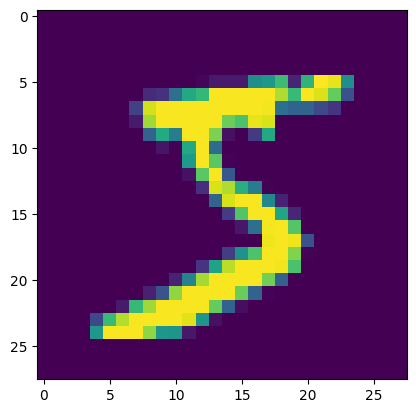

In [8]:
# Show sample image
plt.imshow(X_train[0])
y_train[0]

In [9]:
# Scale the input data in the range from 0 to 1
X_train = X_train / 255
X_test = X_test / 255

In [10]:
# Check for a random sample
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [11]:
# Reshape the input train and test data to flatten it
X_train_flattened = X_train.reshape(len(X_train), 28*28)  # We need to reshape each element to be of single dimension with 28*28 pixels from 2D.
X_test_flattened = X_test.reshape(len(X_test), 28*28)

X_train_flattened.shape, X_test_flattened.shape

((60000, 784), (10000, 784))

In [12]:
# Display flattened sample
X_train_flattened[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [13]:
# Define model
model = keras.Sequential([
    keras.layers.Dense(10, input_shape = (784, ), activation = 'sigmoid')
])

C:\Users\Ciya\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Compile the model
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [15]:
# Train the model
model.fit(X_train_flattened, y_train, validation_data = (X_test_flattened, y_test), epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 771us/step - accuracy: 0.8096 - loss: 0.7224 - val_accuracy: 0.9143 - val_loss: 0.3074
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 706us/step - accuracy: 0.9151 - loss: 0.3090 - val_accuracy: 0.9197 - val_loss: 0.2828
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 724us/step - accuracy: 0.9204 - loss: 0.2820 - val_accuracy: 0.9245 - val_loss: 0.2744
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 799us/step - accuracy: 0.9263 - loss: 0.2676 - val_accuracy: 0.9231 - val_loss: 0.2711
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 775us/step - accuracy: 0.9261 - loss: 0.2668 - val_accuracy: 0.9256 - val_loss: 0.2694


In [16]:
# Evaluate the model performance on test dataset
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step - accuracy: 0.9140 - loss: 0.3089


[0.2694138288497925, 0.925599992275238]

In [25]:
# Predict on test dataset
y_pred = model.predict(X_test_flattened)

y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step


array([[3.1310823e-02, 2.3298820e-07, 7.4422844e-02, ..., 9.9978375e-01,
        1.0370588e-01, 6.1683404e-01],
       [5.3452992e-01, 6.6202604e-03, 9.9942744e-01, ..., 1.2187831e-12,
        1.7399119e-01, 2.2645332e-09],
       [4.3194697e-04, 9.9312049e-01, 6.3106334e-01, ..., 9.6490987e-02,
        4.3358943e-01, 5.5888936e-02],
       ...,
       [5.3186527e-06, 5.2807673e-06, 1.6275079e-03, ..., 1.8454534e-01,
        6.3086766e-01, 8.0599546e-01],
       [2.5608944e-04, 2.0838159e-04, 1.8272118e-04, ..., 4.7460315e-05,
        7.1164602e-01, 1.6919234e-04],
       [1.0855071e-02, 7.8445789e-10, 1.6683173e-01, ..., 1.5149929e-08,
        3.5584008e-04, 8.8736130e-07]], dtype=float32)

In [26]:
# Convert test result to labels
y_classes = [np.argmax(ele) for ele in y_pred]

y_classes

[7,
 2,
 1,
 0,
 4,
 1,
 4,
 9,
 6,
 9,
 0,
 6,
 9,
 0,
 1,
 5,
 9,
 7,
 3,
 4,
 9,
 6,
 6,
 5,
 4,
 0,
 7,
 4,
 0,
 1,
 3,
 1,
 3,
 6,
 7,
 2,
 7,
 1,
 2,
 1,
 1,
 7,
 4,
 2,
 3,
 5,
 1,
 2,
 4,
 4,
 6,
 3,
 5,
 5,
 6,
 0,
 4,
 1,
 9,
 5,
 7,
 8,
 9,
 2,
 7,
 4,
 2,
 4,
 3,
 0,
 7,
 0,
 2,
 9,
 1,
 7,
 3,
 2,
 9,
 7,
 7,
 6,
 2,
 7,
 8,
 4,
 7,
 3,
 6,
 1,
 3,
 6,
 9,
 3,
 1,
 4,
 1,
 7,
 6,
 9,
 6,
 0,
 5,
 4,
 9,
 9,
 2,
 1,
 9,
 4,
 8,
 7,
 3,
 9,
 7,
 4,
 4,
 4,
 9,
 2,
 5,
 4,
 7,
 6,
 4,
 9,
 0,
 5,
 8,
 5,
 6,
 6,
 5,
 7,
 8,
 1,
 0,
 1,
 6,
 4,
 6,
 7,
 3,
 1,
 7,
 1,
 8,
 2,
 0,
 9,
 9,
 8,
 5,
 5,
 1,
 5,
 6,
 0,
 3,
 4,
 4,
 6,
 5,
 4,
 6,
 5,
 4,
 5,
 1,
 4,
 4,
 7,
 2,
 3,
 2,
 7,
 1,
 8,
 1,
 8,
 1,
 8,
 5,
 0,
 8,
 9,
 2,
 5,
 0,
 1,
 1,
 1,
 0,
 3,
 0,
 8,
 1,
 6,
 4,
 2,
 3,
 6,
 1,
 1,
 1,
 3,
 9,
 5,
 2,
 9,
 4,
 7,
 9,
 3,
 9,
 0,
 3,
 6,
 5,
 5,
 7,
 2,
 2,
 7,
 1,
 2,
 8,
 4,
 1,
 7,
 3,
 3,
 8,
 7,
 7,
 9,
 2,
 2,
 4,
 1,
 5,
 8,
 8,
 7,
 2,
 3,
 0,
 2,
 4,
 2,


7

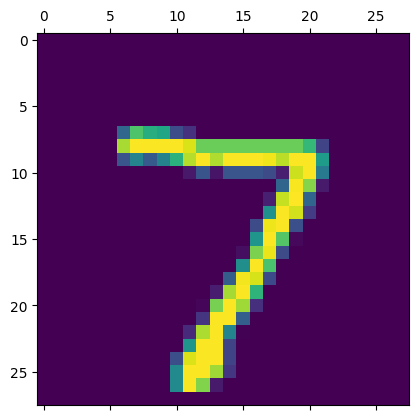

In [27]:
# Verify random test result
plt.matshow(X_test[0])
y_classes[0]  # The test sample is predicted correctly

1

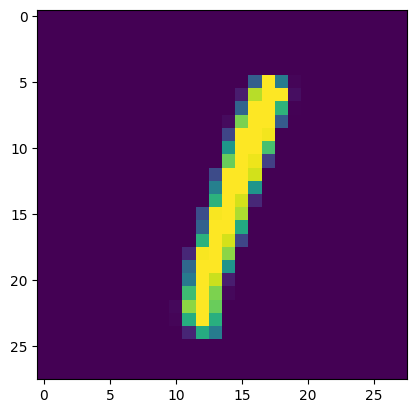

In [29]:
# Try for more samples
plt.imshow(X_test[5])
y_classes[5]

In [33]:
# Let's display confusion matrix
matrix = tf.math.confusion_matrix(labels = y_test, predictions = y_classes)

Text(95.72222222222221, 0.5, 'Actual')

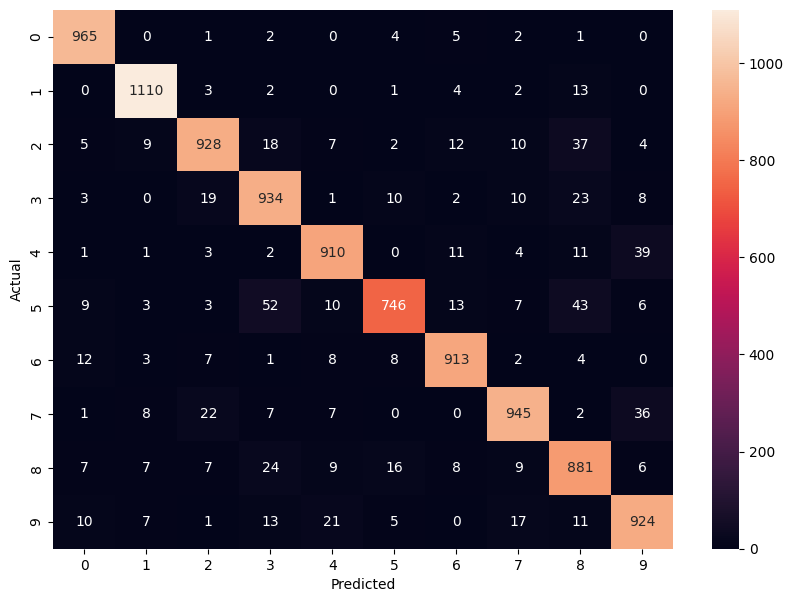

In [34]:
plt.figure(figsize = (10,7))
sns.heatmap(matrix, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Actual')